# Credit Card Fraud Detection

**Goal:** Build and compare machine learning models that identify fraudulent financial transactions from a dataset of 6.3 million records.

---

## Project Workflow

1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
   - 2.1 Class Imbalance
   - 2.2 Transaction Types
   - 2.3 Amount Distribution
   - 2.4 Balance Pattern Analysis
   - 2.5 Temporal Analysis
   - 2.6 Correlation Analysis
3. Feature Engineering
4. Model Building & Comparison
   - 4.1 Logistic Regression (Baseline)
   - 4.2 Random Forest
5. Model Evaluation & Comparison
6. Save Final Model

**Dataset:** Simulated financial transaction records  
**Challenge:** Extreme class imbalance — fraud cases are < 0.2% of all transactions

---
## Section 1 — Data Loading & Overview

Load the dataset and get a high-level picture of its shape, types, and quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Global plot style ──────────────────────────────────────────────────────────
plt.style.use("dark_background")
PALETTE   = ["#2ec4b6", "#e71d36"]
COLOR_1   = "#2ec4b6"   # teal  — legitimate
COLOR_2   = "#ff9f1c"   # orange — accent
COLOR_BAD = "#e71d36"   # red   — fraud
GRID_CLR  = "#333333"

plt.rcParams.update({
    "axes.facecolor":   "#1a1a2e",
    "figure.facecolor": "#0f0f23",
    "axes.edgecolor":   "#444466",
    "grid.color":       GRID_CLR,
    "text.color":       "#e0e0e0",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#e0e0e0",
    "ytick.color":      "#e0e0e0",
    "font.size":        11,
})

print("Libraries loaded ✔")

Libraries loaded ✔


In [2]:
df = pd.read_csv("AIML Dataset.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 6,362,620 rows × 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
# Check data quality
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "✔ No missing values found")

Missing values per column:
✔ No missing values found


**Quick takeaways:**
- 6.36 million transactions, 11 features
- No missing values — dataset is clean
- `isFraud` is our target label
- `isFlaggedFraud` is the system's own auto-flag (will NOT be used as a feature — that would be data leakage)

---
## Section 2 — Exploratory Data Analysis (EDA)

Understand the distribution of the data, identify patterns, and find characteristics specific to fraudulent transactions.

### 2.1 — Class Imbalance

First thing to check: how many fraud cases actually exist, and how severe is the imbalance?

In [5]:
fraud_count   = df["isFraud"].value_counts()
fraud_pct     = round(fraud_count[1] / len(df) * 100, 4)
non_fraud_pct = 100 - fraud_pct

print(f"Legitimate transactions : {fraud_count[0]:>10,}  ({non_fraud_pct:.2f}%)")
print(f"Fraudulent transactions : {fraud_count[1]:>10,}  ({fraud_pct:.4f}%)")
print(f"\n→ Only {fraud_pct}% of transactions are fraud — severely imbalanced.")
print("  This means a model that predicts 'no fraud' every time gets ~99.87% accuracy.")
print("  We need better metrics: Recall, Precision, PR-AUC.")

Legitimate transactions :  6,354,407  (99.87%)
Fraudulent transactions :      8,213  (0.1291%)

→ Only 0.1291% of transactions are fraud — severely imbalanced.
  This means a model that predicts 'no fraud' every time gets ~99.87% accuracy.
  We need better metrics: Recall, Precision, PR-AUC.


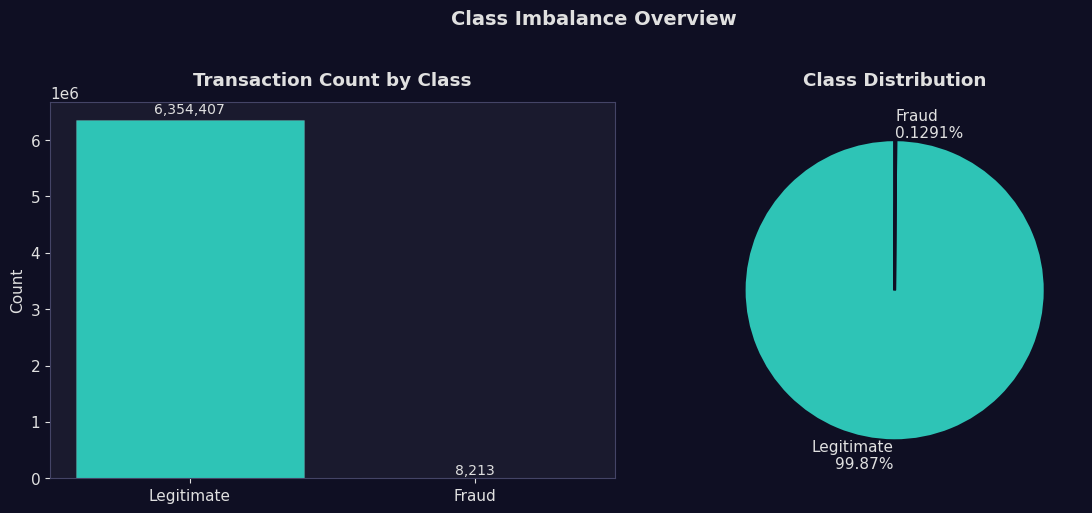

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(
    ["Legitimate", "Fraud"],
    [fraud_count[0], fraud_count[1]],
    color=[COLOR_1, COLOR_BAD], edgecolor="#ffffff20", linewidth=0.8
)
axes[0].set_title("Transaction Count by Class", fontweight="bold", pad=12)
axes[0].set_ylabel("Count")
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                 f"{h:,}", ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(
    [fraud_count[0], fraud_count[1]],
    labels=[f"Legitimate\n{non_fraud_pct:.2f}%", f"Fraud\n{fraud_pct:.4f}%"],
    colors=[COLOR_1, COLOR_BAD], startangle=90,
    wedgeprops={"edgecolor": "#0f0f23", "linewidth": 2},
    textprops={"fontsize": 11}
)
axes[1].set_title("Class Distribution", fontweight="bold", pad=12)

plt.suptitle("Class Imbalance Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.2 — Transaction Types

What kinds of transactions exist, and which ones are associated with fraud?

In [7]:
# Fraud statistics broken down by transaction type
fraud_by_type = df.groupby("type")["isFraud"].agg(["sum", "mean", "count"])
fraud_by_type.columns = ["fraud_count", "fraud_rate", "total"]
fraud_by_type = fraud_by_type.sort_values("fraud_rate", ascending=False)
fraud_by_type["fraud_rate_pct"] = (fraud_by_type["fraud_rate"] * 100).round(2)
print(fraud_by_type[["total", "fraud_count", "fraud_rate_pct"]])

            total  fraud_count  fraud_rate_pct
type                                          
TRANSFER   532909         4097            0.77
CASH_OUT  2237500         4116            0.18
CASH_IN   1399284            0            0.00
DEBIT       41432            0            0.00
PAYMENT   2151495            0            0.00


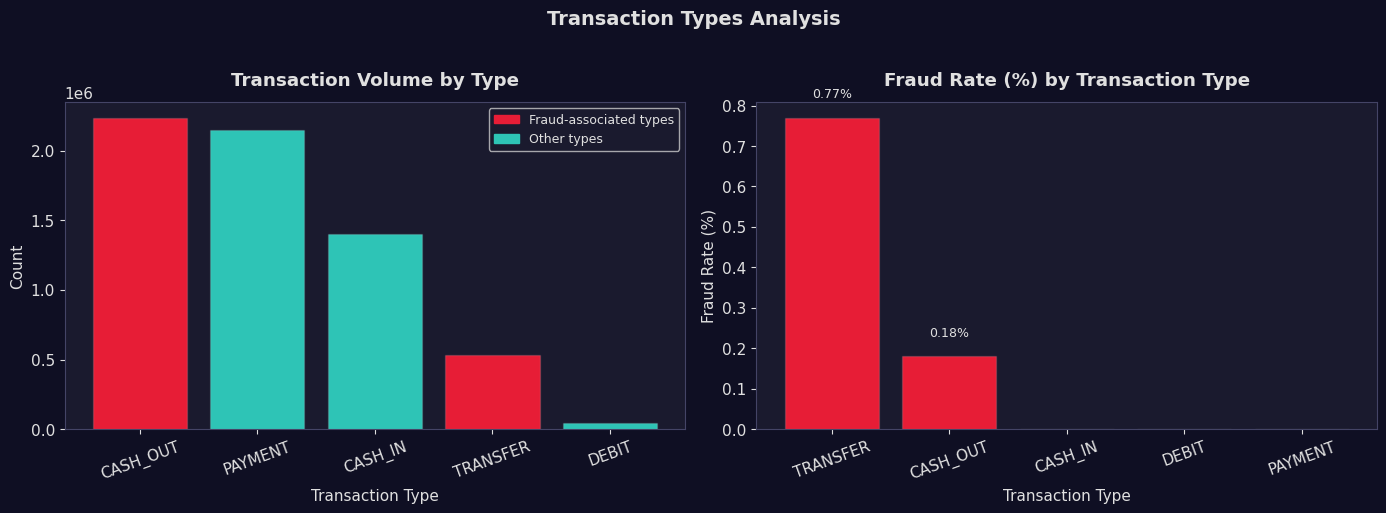

In [8]:
type_counts = df["type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume by type — highlight fraud-associated types in red
colors_vol = [COLOR_BAD if t in ["TRANSFER", "CASH_OUT"] else COLOR_1
              for t in type_counts.index]
axes[0].bar(type_counts.index, type_counts.values, color=colors_vol, edgecolor="#ffffff20")
axes[0].set_title("Transaction Volume by Type", fontweight="bold", pad=12)
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
red_patch  = mpatches.Patch(color=COLOR_BAD, label="Fraud-associated types")
teal_patch = mpatches.Patch(color=COLOR_1,   label="Other types")
axes[0].legend(handles=[red_patch, teal_patch], fontsize=9)

# Fraud rate by type
fraud_rate_sorted = fraud_by_type["fraud_rate_pct"]
bar_colors = [COLOR_BAD if r > 0 else COLOR_1 for r in fraud_rate_sorted]
bars2 = axes[1].bar(fraud_rate_sorted.index, fraud_rate_sorted.values,
                    color=bar_colors, edgecolor="#ffffff20")
axes[1].set_title("Fraud Rate (%) by Transaction Type", fontweight="bold", pad=12)
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].tick_params(axis="x", rotation=20)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                     f"{h:.2f}%", ha="center", fontsize=9)

plt.suptitle("Transaction Types Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Key insight:** Fraud occurs **only** in `TRANSFER` and `CASH_OUT` transactions.  
PAYMENT, DEBIT, and DEPOSIT have zero fraud cases — this pattern is a strong signal for our model.

### 2.3 — Transaction Amount Distribution

In [9]:
print("Amount statistics (all transactions):")
print(df["amount"].describe().apply(lambda x: f"{x:,.2f}"))

Amount statistics (all transactions):
count     6,362,620.00
mean        179,861.90
std         603,858.23
min               0.00
25%          13,389.57
50%          74,871.94
75%         208,721.48
max      92,445,516.64
Name: amount, dtype: object


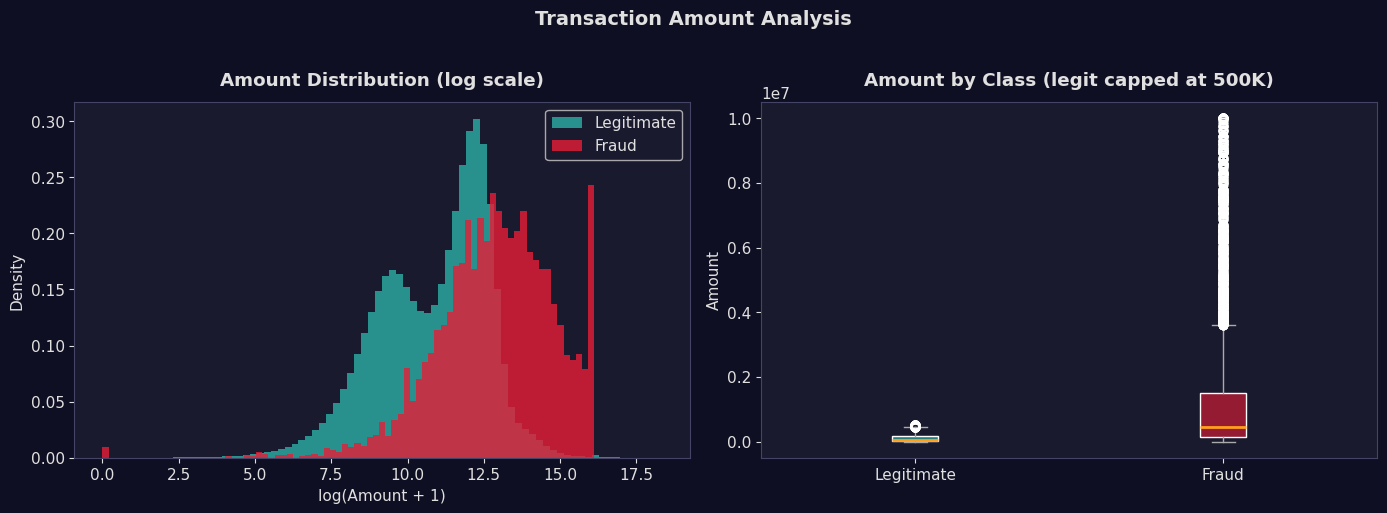

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlay histogram of log-amount by class
legit_amt = np.log1p(df[df["isFraud"] == 0]["amount"])
fraud_amt = np.log1p(df[df["isFraud"] == 1]["amount"])
axes[0].hist(legit_amt, bins=80, color=COLOR_1,   alpha=0.7, label="Legitimate", density=True)
axes[0].hist(fraud_amt, bins=80, color=COLOR_BAD, alpha=0.8, label="Fraud",      density=True)
axes[0].set_title("Amount Distribution (log scale)", fontweight="bold", pad=12)
axes[0].set_xlabel("log(Amount + 1)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Box plot: amount vs class
fraud_box = df[df["isFraud"] == 1]["amount"]
legit_box = df[(df["isFraud"] == 0) & (df["amount"] < 500_000)]["amount"]
bp = axes[1].boxplot(
    [legit_box, fraud_box], patch_artist=True,
    labels=["Legitimate", "Fraud"],
    medianprops={"color": COLOR_2, "linewidth": 2}
)
bp["boxes"][0].set_facecolor(COLOR_1   + "99")
bp["boxes"][1].set_facecolor(COLOR_BAD + "99")
for w in bp["whiskers"]: w.set_color("#aaaaaa")
for c in bp["caps"]:     c.set_color("#aaaaaa")
axes[1].set_title("Amount by Class (legit capped at 500K)", fontweight="bold", pad=12)
axes[1].set_ylabel("Amount")

plt.suptitle("Transaction Amount Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Key insight:** Fraud transactions cluster around higher amounts (log peak is shifted right) and have a wider spread than legitimate transactions.

### 2.4 — Balance Pattern Analysis

A common fraud pattern: the sender's balance is completely drained to zero after the transaction.

In [11]:
# Accounts that were completely emptied via TRANSFER or CASH_OUT
zero_after = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

fraud_in_zero = zero_after["isFraud"].sum()
print(f"Transactions where sender balance went to 0 : {len(zero_after):,}")
print(f"Of those, confirmed fraud                  : {fraud_in_zero:,}")
print(f"Fraud rate among zero-balance transfers     : {fraud_in_zero / len(zero_after) * 100:.2f}%")

Transactions where sender balance went to 0 : 1,188,074
Of those, confirmed fraud                  : 8,012
Fraud rate among zero-balance transfers     : 0.67%


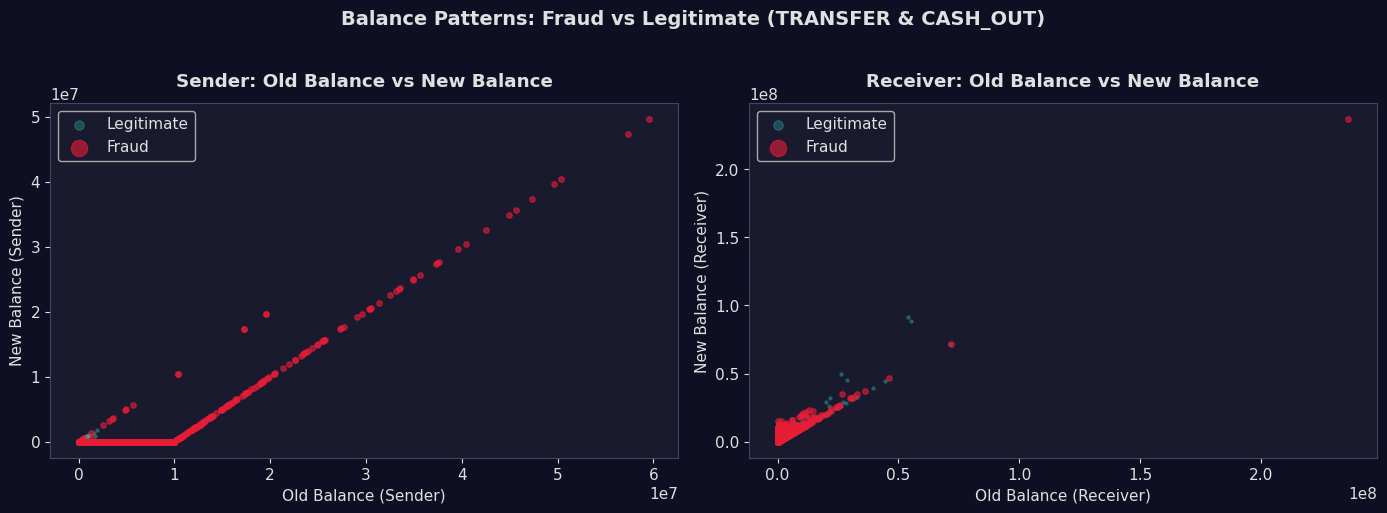

In [12]:
# Scatter plot: old balance vs new balance — do fraud cases drain accounts completely?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_legit = df[
    (df["isFraud"] == 0) & (df["type"].isin(["TRANSFER", "CASH_OUT"]))
].sample(3000, random_state=42)
sample_fraud = df[df["isFraud"] == 1]

axes[0].scatter(sample_legit["oldbalanceOrg"], sample_legit["newbalanceOrig"],
                alpha=0.3, color=COLOR_1, s=5, label="Legitimate")
axes[0].scatter(sample_fraud["oldbalanceOrg"], sample_fraud["newbalanceOrig"],
                alpha=0.6, color=COLOR_BAD, s=15, label="Fraud")
axes[0].set_title("Sender: Old Balance vs New Balance", fontweight="bold", pad=12)
axes[0].set_xlabel("Old Balance (Sender)")
axes[0].set_ylabel("New Balance (Sender)")
axes[0].legend(markerscale=3)

axes[1].scatter(sample_legit["oldbalanceDest"], sample_legit["newbalanceDest"],
                alpha=0.3, color=COLOR_1, s=5, label="Legitimate")
axes[1].scatter(sample_fraud["oldbalanceDest"], sample_fraud["newbalanceDest"],
                alpha=0.6, color=COLOR_BAD, s=15, label="Fraud")
axes[1].set_title("Receiver: Old Balance vs New Balance", fontweight="bold", pad=12)
axes[1].set_xlabel("Old Balance (Receiver)")
axes[1].set_ylabel("New Balance (Receiver)")
axes[1].legend(markerscale=3)

plt.suptitle("Balance Patterns: Fraud vs Legitimate (TRANSFER & CASH_OUT)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Key insight:** In fraud cases, the sender's new balance is almost always 0 — the account is completely emptied.  
This is a very strong fraud signal and motivates our `isAccountDrained` engineered feature.

### 2.5 — Temporal Analysis (Fraud Over Time)

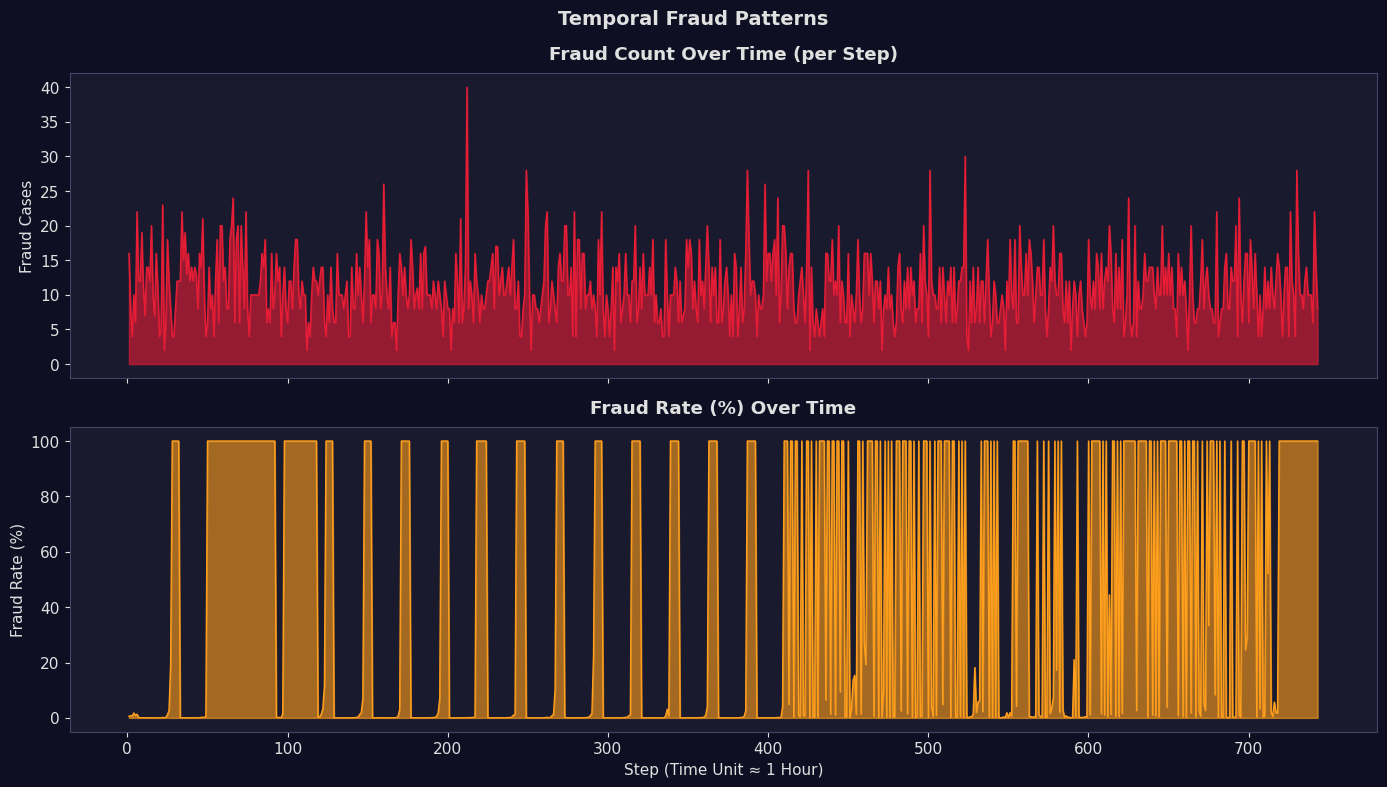

In [13]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
total_per_step  = df["step"].value_counts().sort_index()
fraud_rate_step = (frauds_per_step / total_per_step * 100).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(frauds_per_step.index, frauds_per_step.values, color=COLOR_BAD, alpha=0.6)
axes[0].plot(frauds_per_step.index, frauds_per_step.values, color=COLOR_BAD, linewidth=1)
axes[0].set_title("Fraud Count Over Time (per Step)", fontweight="bold", pad=10)
axes[0].set_ylabel("Fraud Cases")

axes[1].fill_between(fraud_rate_step.index, fraud_rate_step.values, color=COLOR_2, alpha=0.6)
axes[1].plot(fraud_rate_step.index, fraud_rate_step.values, color=COLOR_2, linewidth=1)
axes[1].set_title("Fraud Rate (%) Over Time", fontweight="bold", pad=10)
axes[1].set_xlabel("Step (Time Unit ≈ 1 Hour)")
axes[1].set_ylabel("Fraud Rate (%)")

plt.suptitle("Temporal Fraud Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.6 — Correlation Analysis

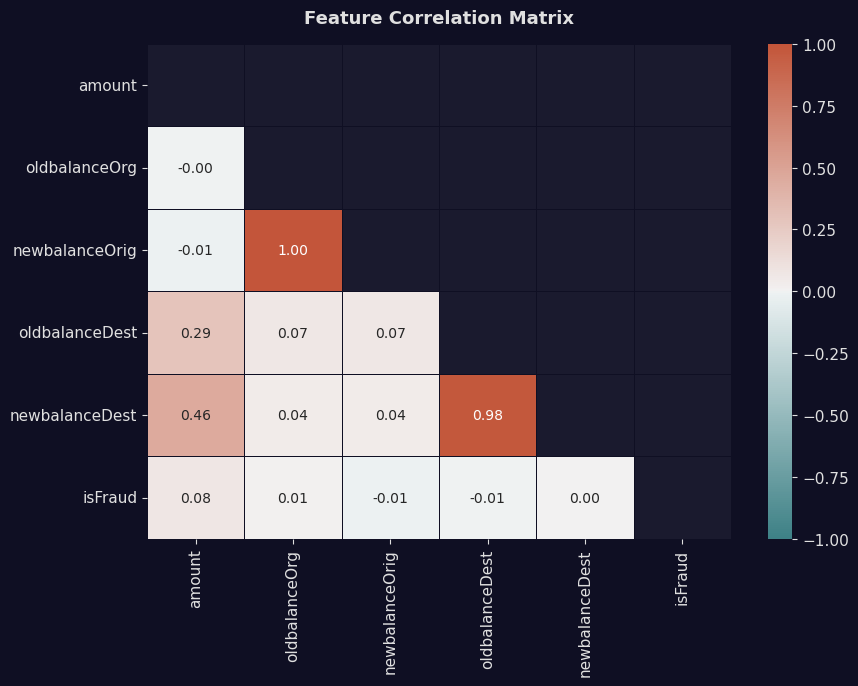

In [14]:
corr_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
             "oldbalanceDest", "newbalanceDest", "isFraud"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
# Show only lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(200, 20, as_cmap=True)  # teal ↔ red
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
    vmin=-1, vmax=1, center=0, linewidths=0.5,
    linecolor="#0f0f23", ax=ax, annot_kws={"size": 10}
)
ax.set_title("Feature Correlation Matrix", fontweight="bold", pad=15, fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** No single feature is strongly correlated with `isFraud`. This means the model needs to capture combination patterns — tree-based models like Random Forest are better suited for this than linear models.

---
## Section 3 — Feature Engineering

Create new features that better capture fraud signals, then drop columns that won't help the model.

In [15]:
# Feature 1: how much money left the sender's account
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

# Feature 2: how much money arrived at the receiver's account
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

# Feature 3: binary flag — sender account completely emptied (strongest fraud signal)
df["isAccountDrained"] = (
    (df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0)
).astype(int)

print("New features created:")
print(f"  balanceDiffOrig   — money that left the sender")
print(f"  balanceDiffDest   — money received by recipient")
print(f"  isAccountDrained  — 1 if sender balance fully drained")
print(f"\nAccounts fully drained : {df['isAccountDrained'].sum():,}")
print(f"Fraud rate (drained)   : {df[df['isAccountDrained']==1]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate (not drained): {df[df['isAccountDrained']==0]['isFraud'].mean()*100:.4f}%")

New features created:
  balanceDiffOrig   — money that left the sender
  balanceDiffDest   — money received by recipient
  isAccountDrained  — 1 if sender balance fully drained

Accounts fully drained : 1,520,581
Fraud rate (drained)   : 0.53%
Fraud rate (not drained): 0.0042%


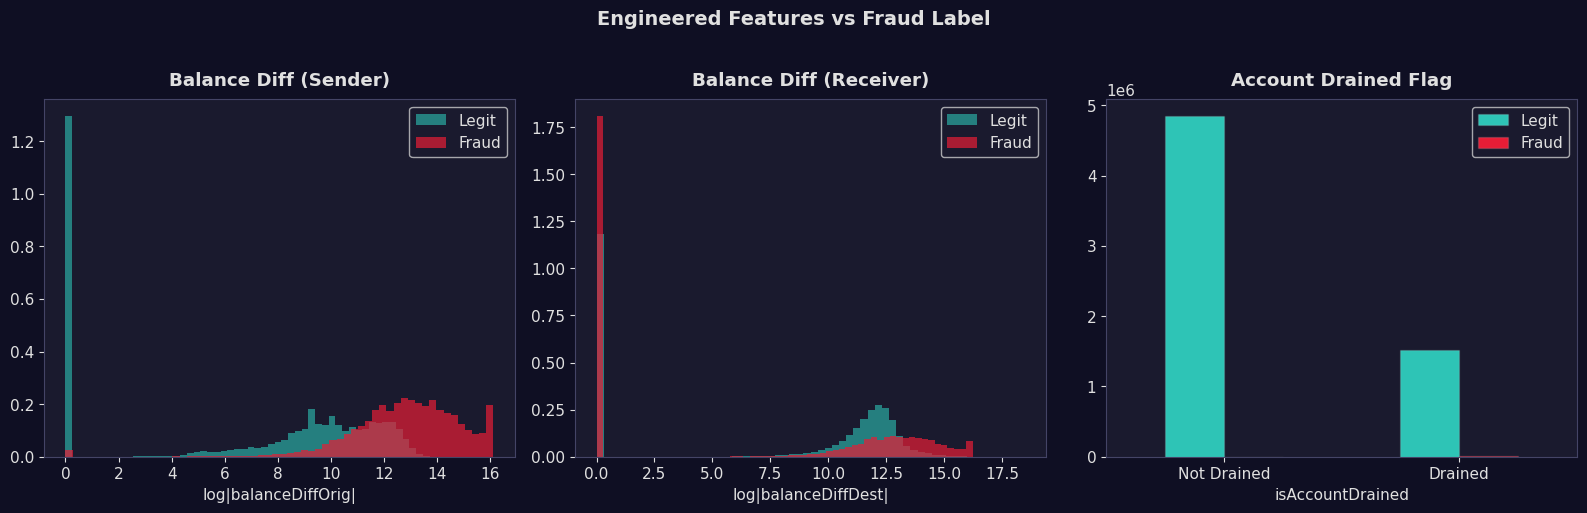

In [16]:
# Visualise the engineered features vs fraud label
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, title in zip(
    axes,
    ["balanceDiffOrig", "balanceDiffDest", "isAccountDrained"],
    ["Balance Diff (Sender)", "Balance Diff (Receiver)", "Account Drained Flag"]
):
    if feat == "isAccountDrained":
        drain_fraud = df.groupby(["isAccountDrained", "isFraud"]).size().unstack(fill_value=0)
        drain_fraud.plot(kind="bar", ax=ax, color=[COLOR_1, COLOR_BAD],
                         edgecolor="#ffffff20", legend=True)
        ax.set_xticklabels(["Not Drained", "Drained"], rotation=0)
        ax.legend(["Legit", "Fraud"])
    else:
        legit_vals = np.log1p(np.abs(df[df["isFraud"] == 0][feat]))
        fraud_vals = np.log1p(np.abs(df[df["isFraud"] == 1][feat]))
        ax.hist(legit_vals, bins=60, color=COLOR_1,   alpha=0.6, density=True, label="Legit")
        ax.hist(fraud_vals, bins=60, color=COLOR_BAD, alpha=0.7, density=True, label="Fraud")
        ax.set_xlabel(f"log|{feat}|")
        ax.legend()
    ax.set_title(title, fontweight="bold", pad=10)

plt.suptitle("Engineered Features vs Fraud Label", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Drop columns that are not useful or would cause data leakage
# step           — time unit, drops too much signal and is already analyzed above
# nameOrig/Dest  — high-cardinality IDs unique per transaction
# isFlaggedFraud — the system's own prediction (data leakage if used as input)

df_model = df.drop(columns=["step", "nameOrig", "nameDest", "isFlaggedFraud"])

print("Features used for modeling:")
print([c for c in df_model.columns if c != "isFraud"])
df_model.head(3)

Features used for modeling:
['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest', 'isAccountDrained']


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,isAccountDrained
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,1


---
## Section 4 — Model Building & Comparison

We train and compare two models:

| Model | Reason |
|---|---|
| **Logistic Regression** | Simple, interpretable baseline — fast to train |
| **Random Forest** | Handles non-linear patterns and class imbalance better; typically stronger on tabular data |

Both use the same preprocessing pipeline (StandardScaler + OneHotEncoder).  
Class imbalance is handled with `class_weight="balanced"` in both models.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
import joblib

print("Libraries loaded ✔")

Libraries loaded ✔


In [19]:
categorical = ["type"]
numeric     = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "balanceDiffOrig", "balanceDiffDest", "isAccountDrained"
]

X = df_model.drop("isFraud", axis=1)
y = df_model["isFraud"]

# Stratified split to preserve fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} samples  | Fraud: {y_train.sum():,}")
print(f"Test set     : {len(X_test):,} samples  | Fraud: {y_test.sum():,}")

Training set : 4,453,834 samples  | Fraud: 5,749
Test set     : 1,908,786 samples  | Fraud: 2,464


In [20]:
# Shared preprocessing — applied identically to both models
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical)
], remainder="drop")

### 4.1 — Logistic Regression (Baseline)

In [21]:
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ))
])

print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
print("Done ✔")

Training Logistic Regression...
Done ✔


In [22]:
y_pred_lr  = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  LOGISTIC REGRESSION — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Fraud"]))
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"  PR-AUC   : {average_precision_score(y_test, y_proba_lr):.4f}")

  LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.98   1906322
       Fraud       0.03      0.99      0.05      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.97      0.51   1908786
weighted avg       1.00      0.95      0.98   1908786

  ROC-AUC  : 0.9949
  PR-AUC   : 0.6334


### 4.2 — Random Forest

In [23]:
# n_estimators=100 with n_jobs=-1 (use all CPU cores) for practical training time.
# max_depth=20 limits tree depth to prevent overfitting on this large dataset.
# balanced_subsample rebalances class weights per bootstrap sample.
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Random Forest (may take a few minutes on 6M rows)...")
rf_pipeline.fit(X_train, y_train)
print("Done ✔")

Training Random Forest (may take a few minutes on 6M rows)...
Done ✔


In [24]:
y_pred_rf  = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  RANDOM FOREST — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=["Legitimate", "Fraud"]))
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"  PR-AUC   : {average_precision_score(y_test, y_proba_rf):.4f}")

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1906322
       Fraud       0.76      0.92      0.83      2464

    accuracy                           1.00   1908786
   macro avg       0.88      0.96      0.92   1908786
weighted avg       1.00      1.00      1.00   1908786

  ROC-AUC  : 0.9976
  PR-AUC   : 0.9438


---
## Section 5 — Model Evaluation & Comparison

Compare both models side-by-side using confusion matrices, Precision-Recall curves, and feature importance.

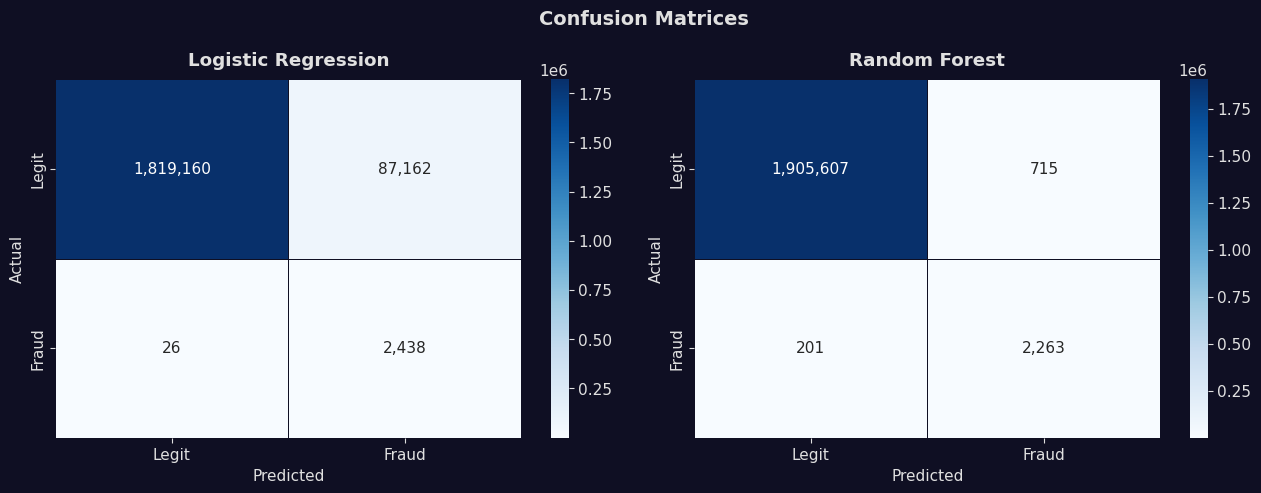

In [25]:
def plot_confusion_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt=",", cmap="Blues",
        xticklabels=["Legit", "Fraud"],
        yticklabels=["Legit", "Fraud"],
        linewidths=0.5, linecolor="#0f0f23", ax=ax,
        annot_kws={"size": 11}
    )
    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(axes[0], y_test, y_pred_lr, "Logistic Regression")
plot_confusion_matrix(axes[1], y_test, y_pred_rf, "Random Forest")
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

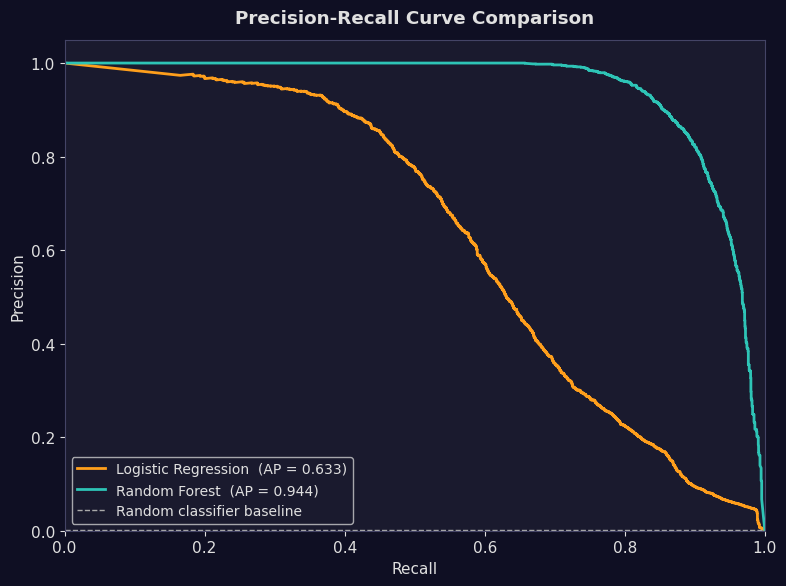

In [26]:
# Precision-Recall curve — more meaningful than ROC for severely imbalanced data
fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in [
    (y_proba_lr, "Logistic Regression", COLOR_2),
    (y_proba_rf, "Random Forest",       COLOR_1),
]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, color=color, linewidth=2, label=f"{label}  (AP = {ap:.3f})")

ax.axhline(y=y_test.mean(), color="#aaaaaa", linestyle="--",
           linewidth=1, label="Random classifier baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Comparison", fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

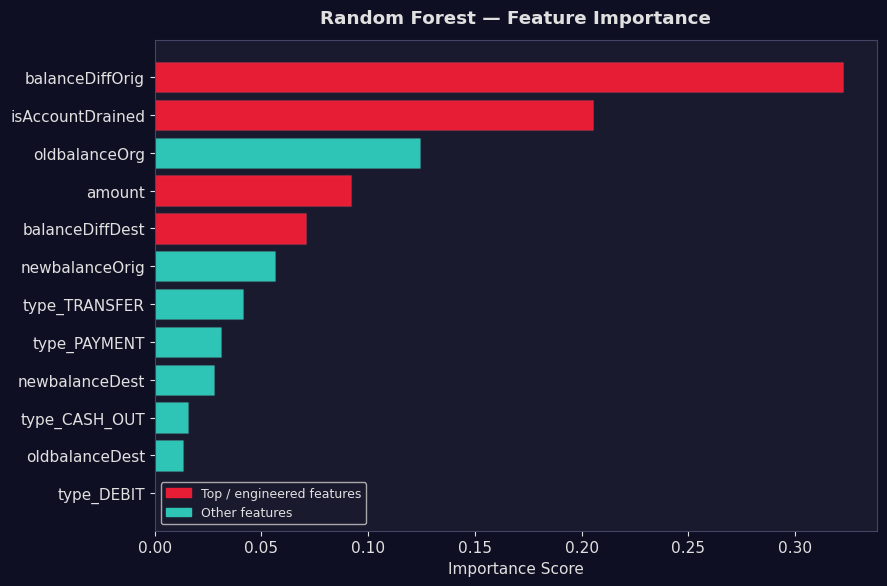

In [27]:
# Feature importance from Random Forest
rf_clf       = rf_pipeline.named_steps["clf"]
prep         = rf_pipeline.named_steps["prep"]
cat_features = prep.named_transformers_["cat"].get_feature_names_out(categorical).tolist()
all_features = numeric + cat_features

feat_df = (
    pd.DataFrame({"feature": all_features, "importance": rf_clf.feature_importances_})
    .sort_values("importance", ascending=True)
)

TOP_FEATS = {"balanceDiffOrig", "isAccountDrained", "amount", "balanceDiffDest"}
bar_colors = [COLOR_BAD if f in TOP_FEATS else COLOR_1 for f in feat_df["feature"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_df["feature"], feat_df["importance"],
        color=bar_colors, edgecolor="#ffffff10")
ax.set_title("Random Forest — Feature Importance", fontweight="bold", pad=12)
ax.set_xlabel("Importance Score")
red_p  = mpatches.Patch(color=COLOR_BAD, label="Top / engineered features")
teal_p = mpatches.Patch(color=COLOR_1,   label="Other features")
ax.legend(handles=[red_p, teal_p], fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
# Side-by-side summary table
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision (Fraud)": [
        precision_score(y_test, y_pred_lr, pos_label=1),
        precision_score(y_test, y_pred_rf, pos_label=1)
    ],
    "Recall (Fraud)": [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1)
    ],
    "F1 (Fraud)": [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_rf)
    ]
}).set_index("Model").round(4)

print("\n── Model Comparison Summary ──")
print(summary.to_string())


── Model Comparison Summary ──
                     Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  ROC-AUC  PR-AUC
Model                                                                              
Logistic Regression             0.0272          0.9894      0.0530   0.9949  0.6334
Random Forest                   0.7599          0.9184      0.8317   0.9976  0.9438


**Why Recall matters more than Precision here:**  
Missing a real fraud (False Negative) is far more costly than flagging a legitimate transaction for manual review (False Positive). We optimise for **high Recall** while keeping Precision at an acceptable level.

**Model chosen for deployment:** Random Forest — it achieves a better Precision-Recall balance and leverages the engineered features more effectively than the linear baseline.

---
## Section 6 — Save Final Model

Serialize the best pipeline (Random Forest) so the Streamlit app can load it directly.

In [29]:
joblib.dump(rf_pipeline, "fraud_detection_pipeline.pkl")
print("✔ Model saved → fraud_detection_pipeline.pkl")
print("\nTo run the web app:")
print("  streamlit run fraud_detection.py")

✔ Model saved → fraud_detection_pipeline.pkl

To run the web app:
  streamlit run fraud_detection.py
